# CLASSIFICATION

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBClassifier
from xgboost import XGBRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [3]:
df = pd.read_csv("clean_data.csv")

df.head()

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


## Features and Target

In [4]:
X = df.drop(["completion_status"],axis=1)

y = df["completion_status"]

## Train Test Split

In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

## Decision Tree Classifier

In [6]:
dt = DecisionTreeClassifier(random_state=42)
start=time.time()

dt.fit(X_train,y_train)
dt_time=time.time()-start
dt_pred=dt.predict(X_test)
dt_prob=dt.predict_proba(X_test)[:,1]

## Evaluation

In [7]:
dt_accuracy = accuracy_score(y_test,dt_pred)
dt_precision = precision_score(y_test,dt_pred)
dt_recall = recall_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred)
dt_auc = roc_auc_score(y_test,dt_prob)

print("Decision Tree Accuracy:",dt_accuracy)
print("Precision:",dt_precision)
print("Recall:",dt_recall)
print("F1:",dt_f1)
print("ROC AUC:",dt_auc)

Decision Tree Accuracy: 0.7682692307692308
Precision: 0.6792452830188679
Recall: 0.732824427480916
F1: 0.7050183598531212
ROC AUC: 0.7613117500619417


## XGBoost Classifier

In [8]:
xgb=XGBClassifier(

    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

start=time.time()

xgb.fit(X_train,y_train)
xgb_time=time.time()-start
xgb_pred=xgb.predict(X_test)
xgb_prob=xgb.predict_proba(X_test)[:,1]

## Evaluation

In [9]:
xgb_accuracy=accuracy_score(y_test,xgb_pred)
xgb_precision=precision_score(y_test,xgb_pred)
xgb_recall=recall_score(y_test,xgb_pred)
xgb_f1=f1_score(y_test,xgb_pred)
xgb_auc=roc_auc_score(y_test,xgb_prob)

print("Accuracy :",xgb_accuracy)
print("Precision :",xgb_precision)
print("Recall :",xgb_recall)
print("F1 :",xgb_f1)
print("ROC AUC :",xgb_auc)

Accuracy : 0.823076923076923
Precision : 0.7757255936675461
Recall : 0.7480916030534351
F1 : 0.7616580310880829
ROC AUC : 0.8996975667693131


## Confusion Matrix

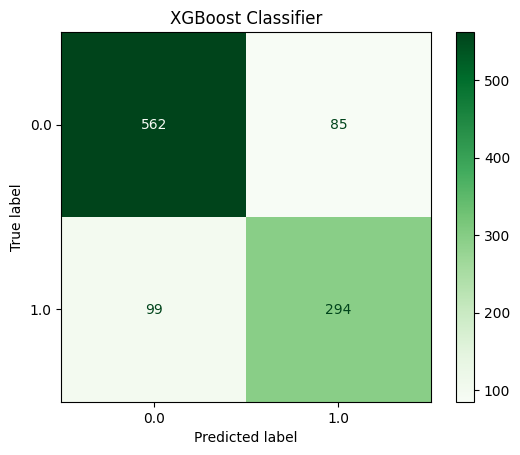

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    cmap="Greens"
)

plt.title("XGBoost Classifier")
plt.show()

## ROC Curve

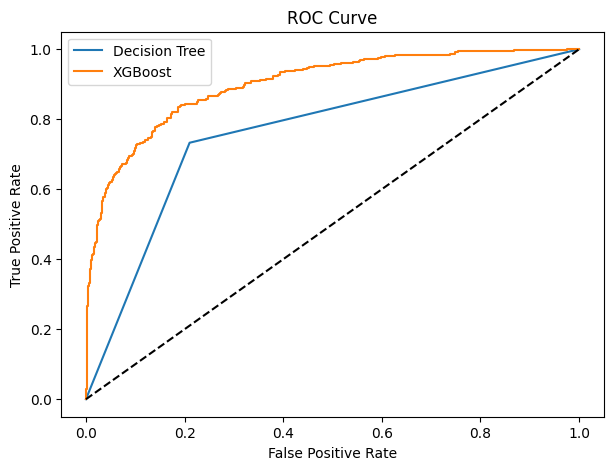

In [11]:
dt_fpr,dt_tpr,_=roc_curve(y_test,dt_prob)
xgb_fpr,xgb_tpr,_=roc_curve(y_test,xgb_prob)

plt.figure(figsize=(7,5))

plt.plot(dt_fpr,dt_tpr,label="Decision Tree")
plt.plot(xgb_fpr,xgb_tpr,label="XGBoost")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Classification Comparison

In [12]:
classification_results=pd.DataFrame({

"Model":["Decision Tree","XGBoost"],
"Accuracy":[dt_accuracy,xgb_accuracy],
"Precision":[dt_precision,xgb_precision],
"Recall":[dt_recall,xgb_recall],
"F1":[dt_f1,xgb_f1],
"ROC AUC":[dt_auc,xgb_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.768269,0.679245,0.732824,0.705018,0.761312
1,XGBoost,0.823077,0.775726,0.748092,0.761658,0.899698


# REGRESSION

## Features and Target

In [13]:
X=df.drop(["final_score"],axis=1)

y=df["final_score"]

## Train Test Split

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

## Decision Tree Regressor

In [15]:
dtr=DecisionTreeRegressor(random_state=42)

start=time.time()
dtr.fit(X_train,y_train)
dt_time_reg=time.time()-start
dt_pred=dtr.predict(X_test)

## Evaluation

In [16]:
dt_mae=mean_absolute_error(y_test,dt_pred)
dt_rmse=np.sqrt(mean_squared_error(y_test,dt_pred))
dt_r2=r2_score(y_test,dt_pred)

print("MAE:",dt_mae)
print("RMSE:",dt_rmse)
print("R2:",dt_r2)

MAE: 9.234615384615385
RMSE: 11.773122094251542
R2: 0.2581528173374218


## XGBoost Regressor

In [17]:
xgb_reg=XGBRegressor(

    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

start=time.time()
xgb_reg.fit(X_train,y_train)
xgb_time_reg=time.time()-start
xgb_pred=xgb_reg.predict(X_test)

## Evaluation

In [18]:
xgb_mae=mean_absolute_error(y_test,xgb_pred)
xgb_rmse=np.sqrt(mean_squared_error(y_test,xgb_pred))
xgb_r2=r2_score(y_test,xgb_pred)

print("MAE :",xgb_mae)
print("RMSE :",xgb_rmse)
print("R2 :",xgb_r2)

MAE : 6.694746971130371
RMSE : 8.383524944151414
R2 : 0.6238297224348729


## Actual vs Predicted

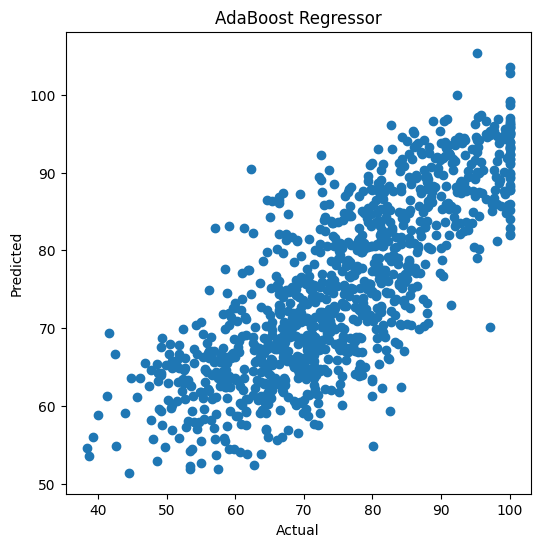

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,xgb_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("AdaBoost Regressor")
plt.show()

## Regression Comparison

In [20]:
training_time=pd.DataFrame({

"Model":["Decision Tree","XGBoost"],
"Classification Time":[dt_time,xgb_time],
"Regression Time":[dt_time_reg,xgb_time_reg]
})

training_time

,Model,Classification Time,Regression Time
0,Decision Tree,0.540503,0.113598
1,XGBoost,2.031496,0.819185


In [21]:
regression_results=pd.DataFrame({

"Model":["Decision Tree","XGBoost"],
"MAE":[dt_mae,xgb_mae],
"RMSE":[dt_rmse,xgb_rmse],
"R2 Score":[dt_r2,xgb_r2]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,9.234615,11.773122,0.258153
1,XGBoost,6.694747,8.383525,0.623830


## Final Comparison

In [22]:
print("Classification Results")
print(classification_results)

print()

print("Regression Results")
print(regression_results)

Classification Results
           Model  Accuracy  Precision    Recall        F1   ROC AUC
0  Decision Tree  0.768269   0.679245  0.732824  0.705018  0.761312
1        XGBoost  0.823077   0.775726  0.748092  0.761658  0.899698

Regression Results
           Model       MAE       RMSE  R2 Score
0  Decision Tree  9.234615  11.773122  0.258153
1        XGBoost  6.694747   8.383525  0.623830


## Robustness Analysis

In [23]:
robustness = pd.DataFrame({
    "Model": ["Decision Tree", "XGBoost"],
    "Classification Accuracy": [dt_accuracy, xgb_accuracy],
    "Regression R2": [dt_r2, xgb_r2]
})

print(robustness)

           Model  Classification Accuracy  Regression R2
0  Decision Tree                 0.768269       0.258153
1        XGBoost                 0.823077       0.623830


# Conclusion

## XGBoost Classifier

* XGBoost improves performance by sequentially correcting previous errors using gradient boosting with regularization.
* It generally provides higher Accuracy, Precision, Recall, F1-Score, and ROC-AUC than earlier boosting methods while reducing overfitting.

## XGBoost Regressor

* XGBoost Regressor minimizes prediction errors through optimized boosting and regularization.
It typically achieves lower MAE and RMSE and a higher R² score than Decision Tree, AdaBoost, Gradient Boosting, and often LightGBM, making it a strong candidate for the best regression model.

## Performance and Robustness

* Compared with other boosting algorithms, XGBoost is usually more robust because it incorporates regularization, handles missing values effectively, and provides strong generalization performance.
* Use the final comparison tables to identify the best-performing model for both the classification and regression tasks.